### Install requirements

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install batchgenerators

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 12.3 MB/s eta 0:00:00
  Created wheel for batchgenerators: filename=batchgenerators-0.25.1-py3-none-any.whl size=93088 sha256=efd90a91a5dc9286e5f07e69c89373523637c68aee78b75b4d469af0cb5fbe1c
  Stored in directory: /root/.cache/pip/wheels/28/21/2b/7b25080f9f5847e6c3162b89d859d7cec9f3093158e56bd008
Successfully built batchgenerators


In [ ]:
!pip install tensorboardX

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 2.9 MB/s eta 0:00:00


In [ ]:
!pip install medpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 19.8 MB/s eta 0:00:00
  Created wheel for medpy: filename=MedPy-0.5.2-py3-none-any.whl size=224710 sha256=3565a59065ef4eeff4b48bf898e9980efd54055c6a89d2da6d827d9ecf5892e3
  Stored in directory: /root/.cache/pip/wheels/89/5a/f8/b3def53b9c2133d2f8698ea2173bb5df63bd8e761ce8e9aec9
Successfully built medpy


In [ ]:
!pip install efficientnet_pytorch

  Preparing metadata (setup.py) ... done
  Created wheel for efficientnet_pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16426 sha256=8efe176731a3af30a70b1d8edeaa59d97794dc21911dffd7b0c8f8ac4ed34679
  Stored in directory: /root/.cache/pip/wheels/9c/3f/43/e6271c7026fe08c185da2be23c98c8e87477d3db63f41f32ad
Successfully built efficientnet_pytorch


In [ ]:
!pip install yacs

In [ ]:
%cd /content/drive/MyDrive/prj/Project_ind/ACDC/SSL4MIS-master/SSL4MIS-master/model/ACDC

/content/drive/.shortcut-targets-by-id/1vsyJDW9ILzHHhEeKu3Af6AwF8FiSnpp6/Project_ind/ACDC/SSL4MIS-master/SSL4MIS-master/model/ACDC


### Available models

In [ ]:
!which python
!pwd

/usr/local/bin/python
/content/drive/.shortcut-targets-by-id/1vsyJDW9ILzHHhEeKu3Af6AwF8FiSnpp6/Project_ind/ACDC/SSL4MIS-master/SSL4MIS-master/model/ACDC


In [ ]:
!ls

Adversarial_Network_14_labeled	Fully_Supervised_70_labeled
Adversarial_Network_7_labeled	Fully_Supervised_7_labeled
CPS_14_labeled			Fully_Supervised_80_labeled
CPS_7_labeled			Mean_Teacher_14_labeled
CPS_7_labeled_1			Mean_Teacher_70_labeled
Fully_Supervised_14_labeled	Mean_Teacher_7_labeled
Fully_Supervised_3D		Mean_Teacher_80_labeled


### Visualize One patients without diffrect

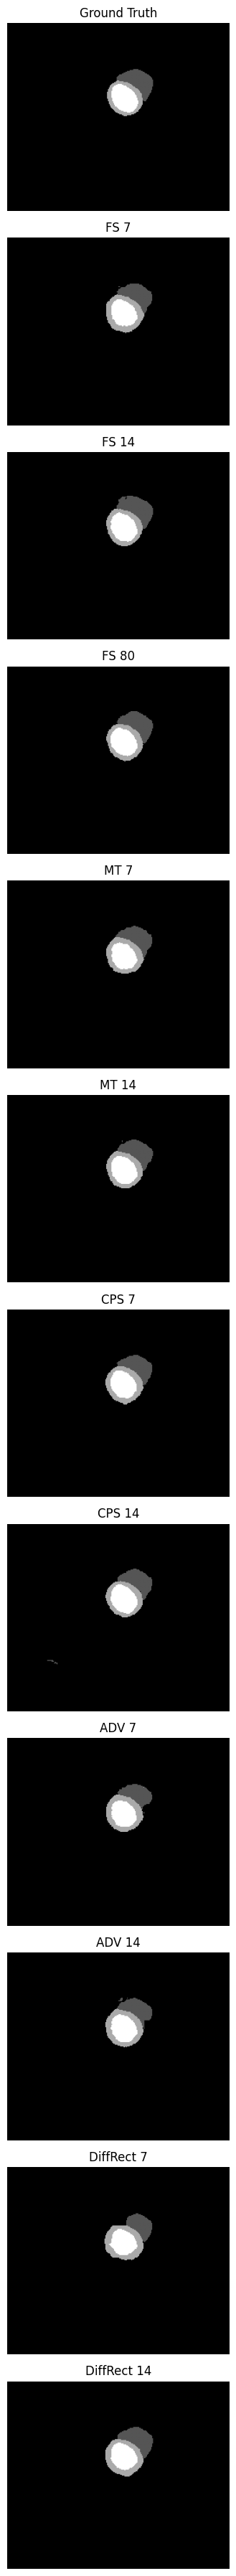

In [ ]:
import os
import nibabel as nib
import matplotlib.pyplot as plt

# Base paths
base_dir_models = "/content/drive/MyDrive/prj/Project_ind/ACDC/SSL4MIS-master/SSL4MIS-master/model/ACDC"
base_dir_diffrect = "/content/drive/MyDrive/prj/Project_ind/ACDC/DiffRect-main/DiffRect-main/logs/ACDC"

methods = {
    "FS 7": ("Fully_Supervised_7_labeled", "efficient_unet_predictions", base_dir_models),
    "FS 14": ("Fully_Supervised_14_labeled", "efficient_unet_predictions", base_dir_models),
    "FS 80": ("Fully_Supervised_80_labeled", "efficient_unet_predictions", base_dir_models),
    "MT 7": ("Mean_Teacher_7_labeled", "efficient_unet_predictions", base_dir_models),
    "MT 14": ("Mean_Teacher_14_labeled", "efficient_unet_predictions", base_dir_models),
    "CPS 7": ("CPS_7_labeled", "efficient_unet_predictions", base_dir_models),
    "CPS 14": ("CPS_14_labeled", "efficient_unet_predictions", base_dir_models),
    "ADV 7": ("Adversarial_Network_7_labeled", "efficient_unet_predictions", base_dir_models),
    "ADV 14": ("Adversarial_Network_14_labeled", "efficient_unet_predictions", base_dir_models),

    # DiffRect (different folder + different prediction directory)
    "DiffRect 7": ("DiffRect_7_labeled", "predictions", base_dir_diffrect),
    "DiffRect 14": ("DiffRect_14_labeled", "predictions", base_dir_diffrect),
}

sample = "patient110_frame01"

results = {}

# Load predictions
for name, (folder, pred_folder, base_dir) in methods.items():

    pred_path = os.path.join(
        base_dir,
        folder,
        pred_folder,
        f"{sample}_pred.nii.gz"
    )

    if os.path.exists(pred_path):
        img = nib.load(pred_path).get_fdata()
        results[name] = img[:, :, img.shape[2] // 2]


# Ground Truth (from fully supervised)
gt_path = os.path.join(
    base_dir_models,
    "Fully_Supervised_80_labeled",
    "efficient_unet_predictions",
    f"{sample}_gt.nii.gz"
)

gt = nib.load(gt_path).get_fdata()
gt_slice = gt[:, :, gt.shape[2] // 2]


# Plot results vertically
rows = len(results) + 1
plt.figure(figsize=(5, 3 * rows))

plt.subplot(rows, 1, 1)
plt.imshow(gt_slice, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

for i, (name, img) in enumerate(results.items()):
    plt.subplot(rows, 1, i + 2)
    plt.imshow(img, cmap="gray")
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Visualize 5 patients with DiffRect

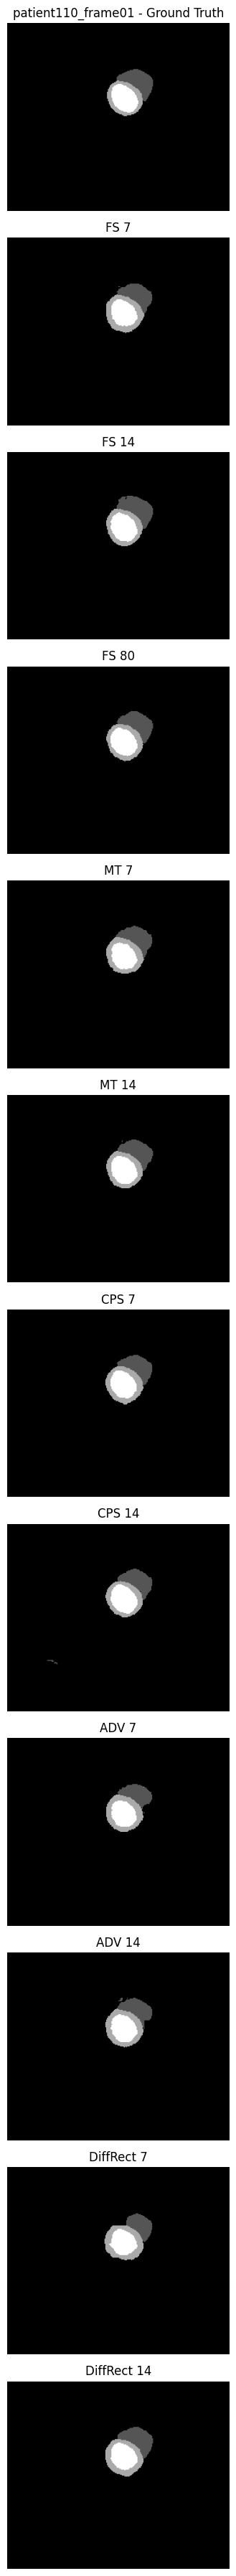

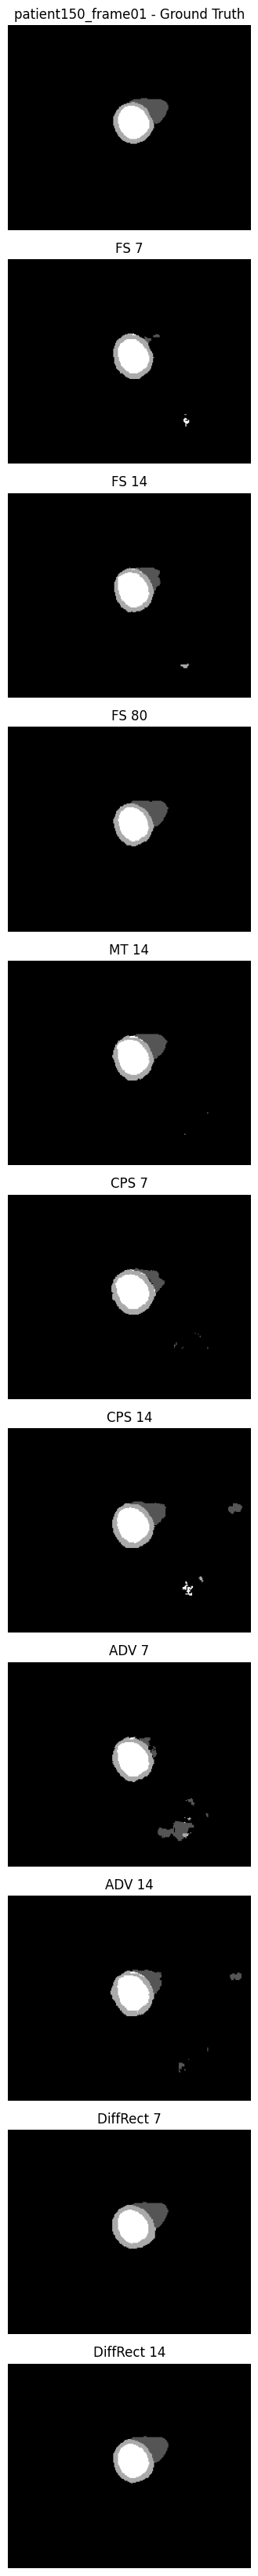

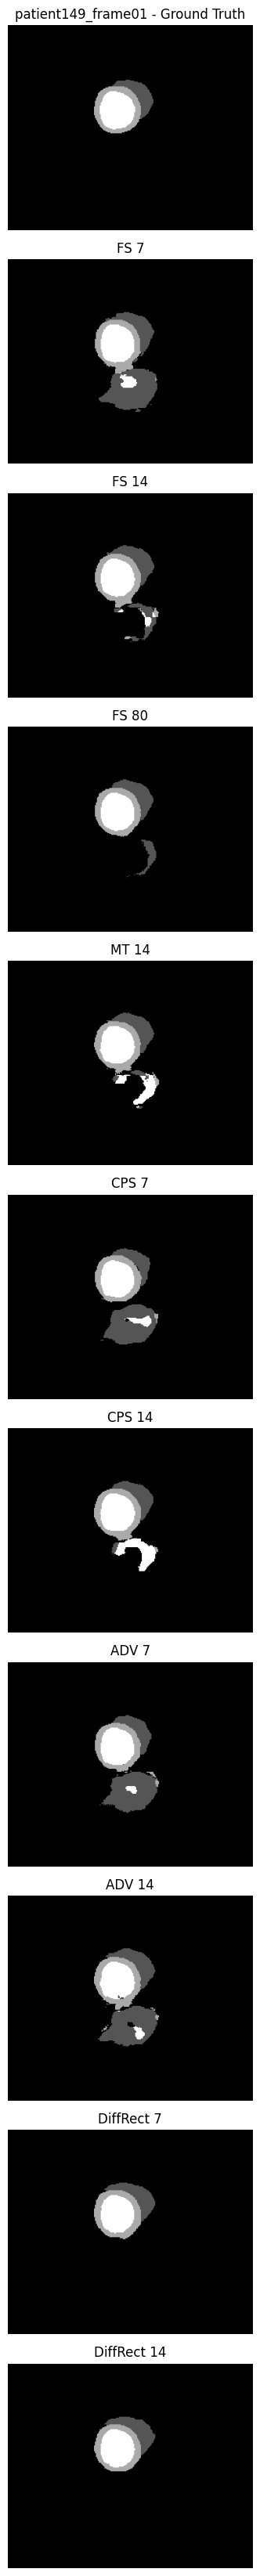

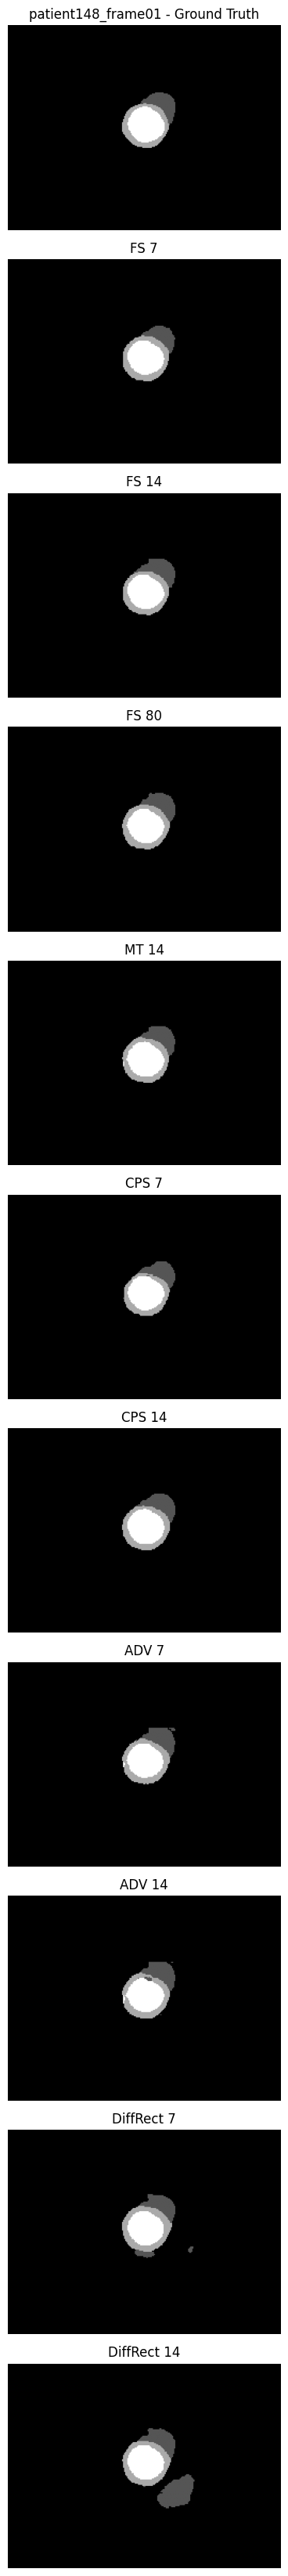

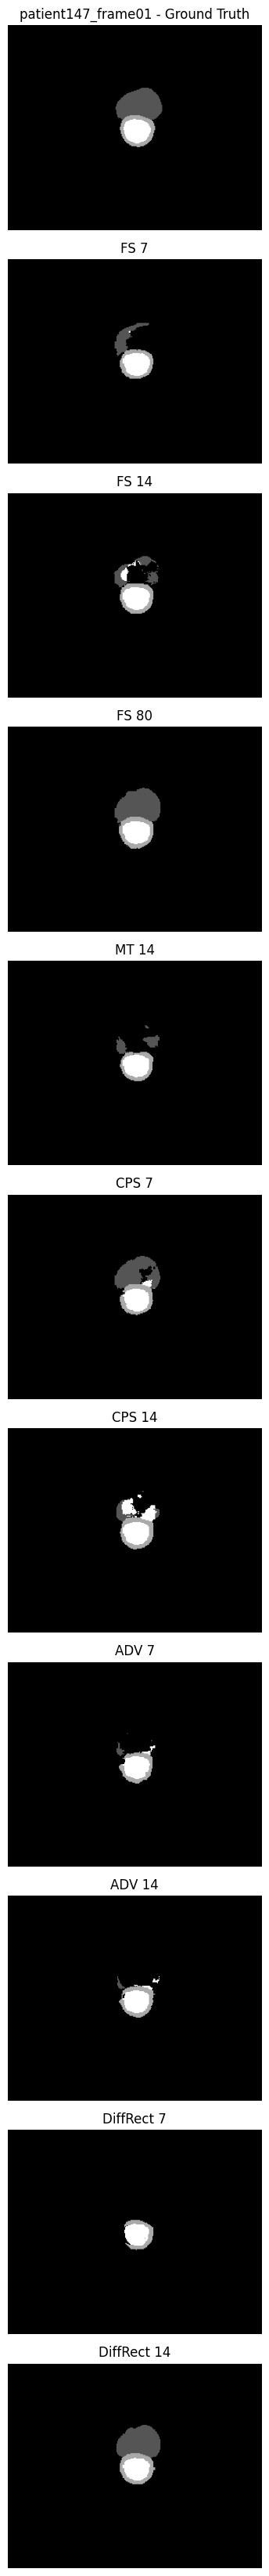

In [ ]:
import os
import nibabel as nib
import matplotlib.pyplot as plt

# Base paths
base_dir_models = "/content/drive/MyDrive/prj/Project_ind/ACDC/SSL4MIS-master/SSL4MIS-master/model/ACDC"
base_dir_diffrect = "/content/drive/MyDrive/prj/Project_ind/ACDC/DiffRect-main/DiffRect-main/logs/ACDC"

methods = {
    "FS 7": ("Fully_Supervised_7_labeled", "efficient_unet_predictions", base_dir_models),
    "FS 14": ("Fully_Supervised_14_labeled", "efficient_unet_predictions", base_dir_models),
    "FS 80": ("Fully_Supervised_80_labeled", "efficient_unet_predictions", base_dir_models),
    "MT 7": ("Mean_Teacher_7_labeled", "efficient_unet_predictions", base_dir_models),
    "MT 14": ("Mean_Teacher_14_labeled", "efficient_unet_predictions", base_dir_models),
    "CPS 7": ("CPS_7_labeled", "efficient_unet_predictions", base_dir_models),
    "CPS 14": ("CPS_14_labeled", "efficient_unet_predictions", base_dir_models),
    "ADV 7": ("Adversarial_Network_7_labeled", "efficient_unet_predictions", base_dir_models),
    "ADV 14": ("Adversarial_Network_14_labeled", "efficient_unet_predictions", base_dir_models),

    # DiffRect
    "DiffRect 7": ("DiffRect_7_labeled", "predictions", base_dir_diffrect),
    "DiffRect 14": ("DiffRect_14_labeled", "predictions", base_dir_diffrect),
}

# 5 patients
patients = [
    "patient110_frame01",
    "patient150_frame01",
    "patient149_frame01",
    "patient148_frame01",
    "patient147_frame01"
]

for sample in patients:

    results = {}

    # Load predictions
    for name, (folder, pred_folder, base_dir) in methods.items():

        pred_path = os.path.join(
            base_dir,
            folder,
            pred_folder,
            f"{sample}_pred.nii.gz"
        )

        if os.path.exists(pred_path):
            img = nib.load(pred_path).get_fdata()
            results[name] = img[:, :, img.shape[2] // 2]

    # Load GT
    gt_path = os.path.join(
        base_dir_models,
        "Fully_Supervised_80_labeled",
        "efficient_unet_predictions",
        f"{sample}_gt.nii.gz"
    )

    if not os.path.exists(gt_path):
        continue

    gt = nib.load(gt_path).get_fdata()
    gt_slice = gt[:, :, gt.shape[2] // 2]

    # Plot
    rows = len(results) + 1
    plt.figure(figsize=(5, 3 * rows))

    plt.subplot(rows, 1, 1)
    plt.imshow(gt_slice, cmap="gray")
    plt.title(f"{sample} - Ground Truth")
    plt.axis("off")

    for i, (name, img) in enumerate(results.items()):
        plt.subplot(rows, 1, i + 2)
        plt.imshow(img, cmap="gray")
        plt.title(name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()